In [ ]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# Paleta de cores
VINHO = "#722F37"
VINHO_CLARO = "#B76E79"
VINHO_ESCURO = "#4A1720"
ROSE = "#D8A0A6"

# Estilo dos gráficos
sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (10, 5)


### Comparação dos Modelos
## KNN × Regressão Logística




In [ ]:
# Carregamento do dataset
# Mantenha o arquivo WineQT.csv no mesmo diretório do notebook.
df = pd.read_csv("../data/WineQT.csv")

print("Dimensões da base:", df.shape)
display(df.head())


Dimensões da base: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 3.1 Variável-alvo

- **0:** baixa/média qualidade (`quality < 7`)
- **1:** alta qualidade (`quality >= 7`)


In [ ]:
df["quality_binary"] = (df["quality"] >= 7).astype(int)

distribuicao = pd.DataFrame({
    "Quantidade": df["quality_binary"].value_counts().sort_index(),
    "Percentual (%)": (
        df["quality_binary"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})
distribuicao.index = ["Baixa/Média", "Alta"]

display(distribuicao)


,Quantidade,Percentual (%)
Baixa/Média,984,86.09
Alta,159,13.91


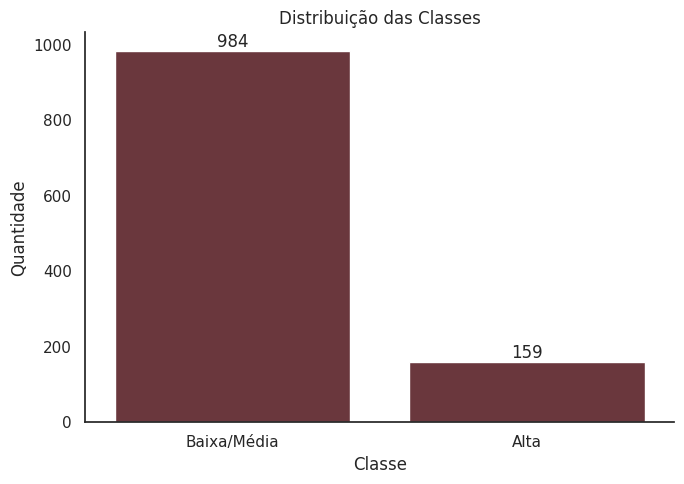

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(
    x=df["quality_binary"],
    color=VINHO
)
plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Baixa/Média", "Alta"])

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.tight_layout()
plt.show()


### Observação

Apenas **13,91%** dos vinhos são de alta qualidade. Por isso, além da Accuracy, serão consideradas métricas como Precision, Recall, F1-score e ROC-AUC.


# 4. Variáveis utilizadas

Os dois modelos atualizados utilizam exatamente as mesmas cinco variáveis:

- `alcohol`
- `citric acid`
- `pH`
- `density`
- `sulphates`

Logo, **não existe diferença nas features utilizadas** entre KNN e Regressão Logística.


In [ ]:
features = [
    "alcohol",
    "citric acid",
    "pH",
    "density",
    "sulphates"
]

X = df[features].copy()
y = df["quality_binary"].copy()

display(pd.DataFrame({"Variável": features}))
print(f"Total: {len(features)} variáveis")


,Variável
0,alcohol
1,citric acid
2,pH
3,density
4,sulphates


Total: 5 variáveis


# 5. Divisão treino/teste

Os dois notebooks utilizam **80% treino e 20% teste**, com `random_state=42` e `stratify=y`. Assim, ambos são avaliados nos mesmos registros.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição percentual no treino:")
display((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nDistribuição percentual no teste:")
display((y_test.value_counts(normalize=True).sort_index() * 100).round(2))


Treino: (914, 5)
Teste: (229, 5)

Distribuição percentual no treino:


,proportion
quality_binary,
0,86.11
1,13.89



Distribuição percentual no teste:


,proportion
quality_binary,
0,86.03
1,13.97


# 6. StandardScaler

Os dois modelos utilizam `StandardScaler`. O scaler é ajustado somente no treino e aplicado ao teste, evitando data leakage e deixando as variáveis em escalas comparáveis.


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=features
)

display(X_train_scaled_df.describe().loc[["mean", "std"]].round(3))


,alcohol,citric acid,pH,density,sulphates
mean,-0.000,-0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001


A padronização é especialmente importante para o KNN, pois o algoritmo utiliza distâncias entre observações.


# 7. Modelo 1 — KNN

Configuração mantida conforme o notebook atual: **`KNeighborsClassifier(n_neighbors=6)`**.


In [ ]:
modelo_knn = KNeighborsClassifier(n_neighbors=6)

modelo_knn.fit(X_train_scaled, y_train)

pred_knn = modelo_knn.predict(X_test_scaled)
prob_knn = modelo_knn.predict_proba(X_test_scaled)[:, 1]

print("KNN treinado com K=6.")


KNN treinado com K=6.


# 8. Modelo 2 — Regressão Logística

Configuração mantida conforme o notebook atual: `class_weight='balanced'`, `random_state=42` e `max_iter=1000`.


In [ ]:
modelo_logistico = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

modelo_logistico.fit(X_train_scaled, y_train)

pred_log = modelo_logistico.predict(X_test_scaled)
prob_log = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

print("Regressão Logística treinada.")


Regressão Logística treinada.


# 9. Diagnóstico das Variáveis

Como os dois modelos usam as mesmas cinco features, analisamos sua comparabilidade e relação com a qualidade.


In [ ]:
diagnostico_variaveis = pd.DataFrame({
    "Variável": features,
    "KNN": ["Utilizada"] * len(features),
    "Regressão Logística": ["Utilizada"] * len(features),
    "Comparável": ["Sim"] * len(features)
})
display(diagnostico_variaveis)


,Variável,KNN,Regressão Logística,Comparável
0,alcohol,Utilizada,Utilizada,Sim
1,citric acid,Utilizada,Utilizada,Sim
2,pH,Utilizada,Utilizada,Sim
3,density,Utilizada,Utilizada,Sim
4,sulphates,Utilizada,Utilizada,Sim


## 9.1 Distribuição das variáveis por classe

Os boxplots mostram como cada feature se comporta entre vinhos de baixa/média e alta qualidade.


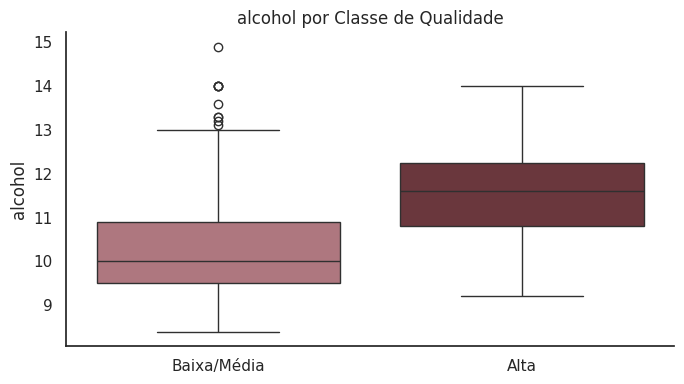

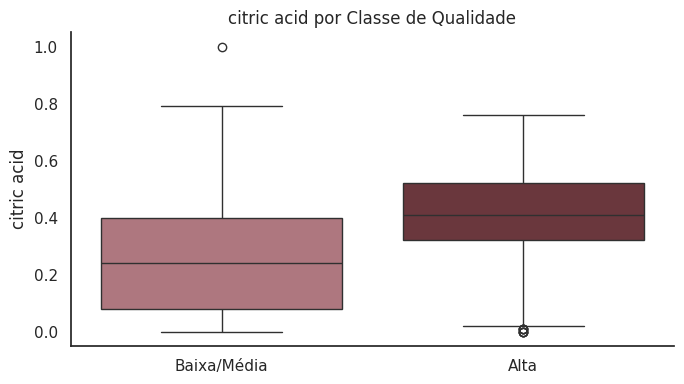

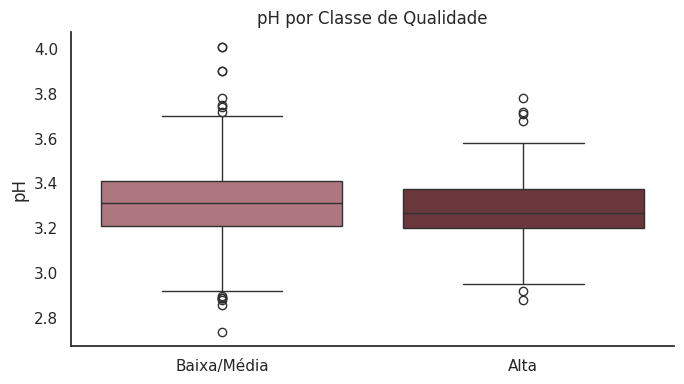

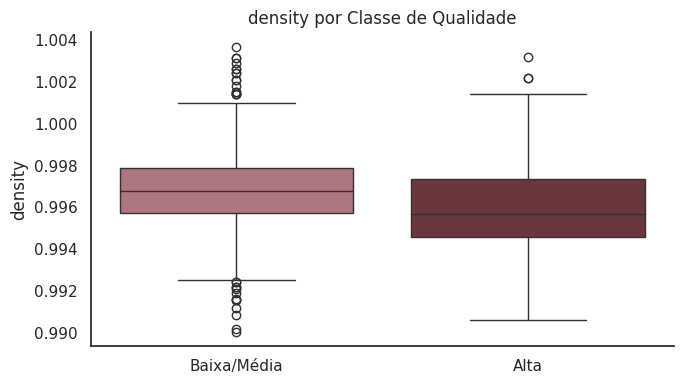

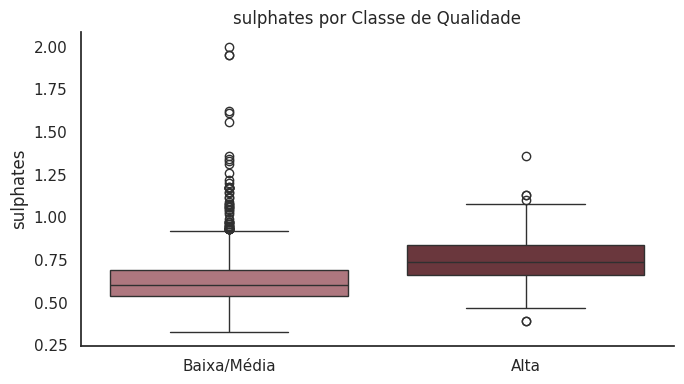

In [ ]:
for col in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df, x="quality_binary", y=col,
        hue="quality_binary",
        palette={0: VINHO_CLARO, 1: VINHO},
        legend=False
    )
    plt.xticks([0, 1], ["Baixa/Média", "Alta"])
    plt.title(f"{col} por Classe de Qualidade")
    plt.xlabel("")
    sns.despine()
    plt.tight_layout()
    plt.show()


## 9.2 Correlação das features com Alta Qualidade

O ranking indica quais das cinco variáveis apresentam maior associação linear com o target.


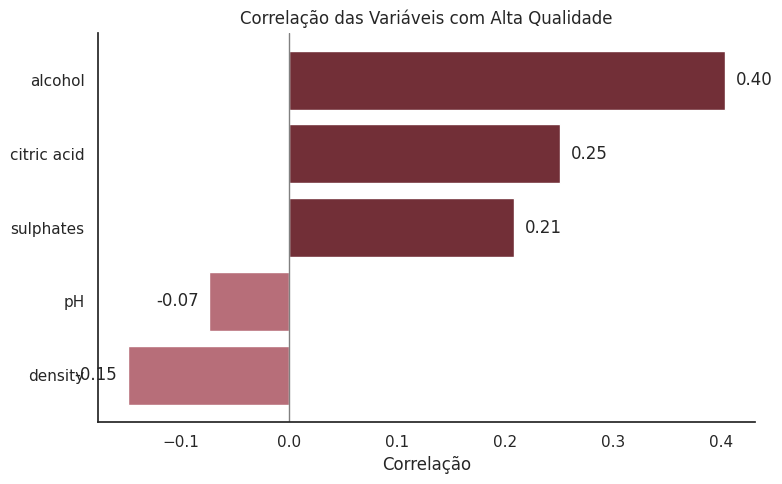

,Correlação
density,-0.149
pH,-0.073
sulphates,0.208
citric acid,0.251
alcohol,0.404


In [ ]:
corr_target = (
    df[features + ["quality_binary"]]
    .corr()["quality_binary"]
    .drop("quality_binary")
    .sort_values()
)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    corr_target.index,
    corr_target.values,
    color=[VINHO_CLARO if v < 0 else VINHO for v in corr_target.values]
)
plt.axvline(0, color="gray", linewidth=1)
plt.title("Correlação das Variáveis com Alta Qualidade")
plt.xlabel("Correlação")
plt.ylabel("")

for bar, value in zip(bars, corr_target.values):
    plt.text(
        value + (0.01 if value >= 0 else -0.01),
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

sns.despine()
plt.tight_layout()
plt.show()
display(corr_target.to_frame("Correlação").round(3))


## 9.3 Diferença das médias por classe

A comparação mostra quanto a média de cada variável muda entre a classe Alta e a classe Baixa/Média.


,Baixa/Média,Alta,Diferença (%)
alcohol,10.267,11.528,12.291
citric acid,0.249,0.391,57.412
pH,3.316,3.282,-1.001
density,0.997,0.996,-0.083
sulphates,0.643,0.746,15.911


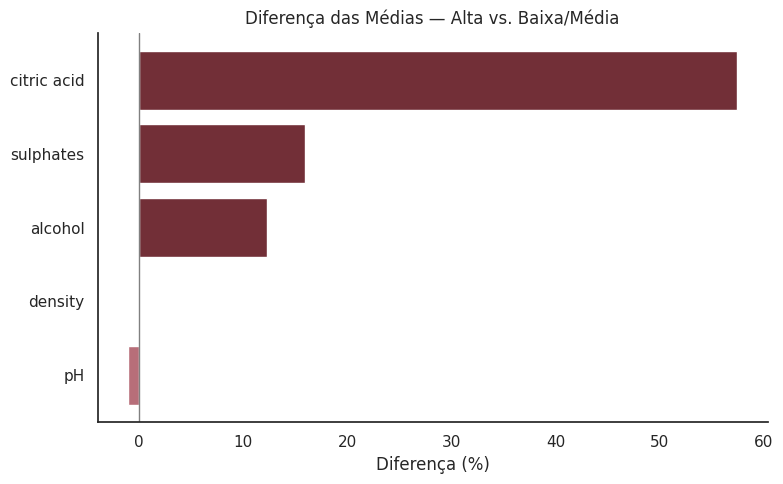

In [ ]:
medias = df.groupby("quality_binary")[features].mean().T
medias.columns = ["Baixa/Média", "Alta"]
medias["Diferença (%)"] = (
    (medias["Alta"] - medias["Baixa/Média"]) /
    medias["Baixa/Média"] * 100
)

display(medias.round(3))

ordenado = medias["Diferença (%)"].sort_values()
plt.figure(figsize=(8, 5))
plt.barh(
    ordenado.index,
    ordenado.values,
    color=[VINHO_CLARO if v < 0 else VINHO for v in ordenado.values]
)
plt.axvline(0, color="gray", linewidth=1)
plt.title("Diferença das Médias — Alta vs. Baixa/Média")
plt.xlabel("Diferença (%)")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()


### Diagnóstico das variáveis

As cinco features são **100% comparáveis** entre os modelos e recebem o mesmo `StandardScaler`.

Portanto, as diferenças de desempenho não são causadas por conjuntos de variáveis diferentes, mas principalmente pela forma como cada algoritmo aprende os padrões da base.


# Comparação Geral das Métricas

In [ ]:
def metricas_modelo(y_true, pred, prob):
    return [
        accuracy_score(y_true, pred),
        precision_score(y_true, pred, zero_division=0),
        recall_score(y_true, pred, zero_division=0),
        f1_score(y_true, pred, zero_division=0),
        roc_auc_score(y_true, prob)
    ]

resultados = pd.DataFrame({
    "KNN": metricas_modelo(y_test, pred_knn, prob_knn),
    "Regressão Logística": metricas_modelo(y_test, pred_log, prob_log)
}, index=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"])

resultados["Diferença KNN - Logística"] = (
    resultados["KNN"] - resultados["Regressão Logística"]
)

display(resultados.round(4))


,KNN,Regressão Logística,Diferença KNN - Logística
Accuracy,0.8821,0.7817,0.1004
Precision,0.6316,0.3548,0.2767
Recall,0.3750,0.6875,-0.3125
F1-score,0.4706,0.4681,0.0025
ROC-AUC,0.8091,0.8031,0.0059


## 9.1 Comparação visual das métricas

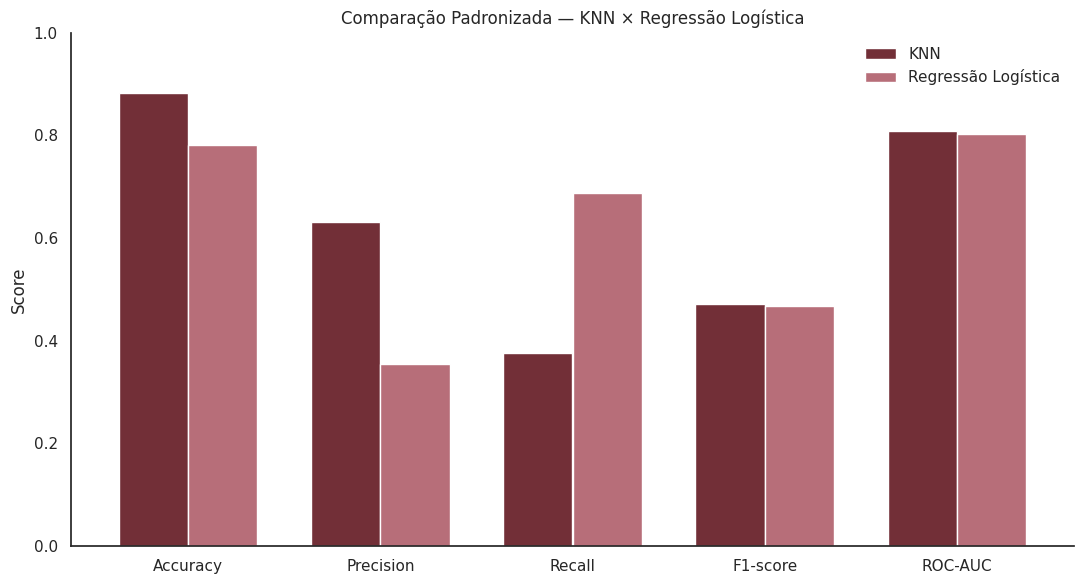

In [ ]:
resultados[["KNN", "Regressão Logística"]].plot(
    kind="bar",
    figsize=(11, 6),
    color=[VINHO, VINHO_CLARO],
    width=0.72
)

plt.title("Comparação Padronizada — KNN × Regressão Logística")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


### Resultado geral

O **KNN** apresentou maior Accuracy (88,21%) e Precision (63,16%). Já a **Regressão Logística** obteve Recall superior (68,75%), enquanto F1-score (46,81%) e ROC-AUC (80,31%) ficaram ligeiramente abaixo do KNN.

Como a classe de alta qualidade é minoritária, F1 e Recall são especialmente relevantes.


# Matrizes de Confusão

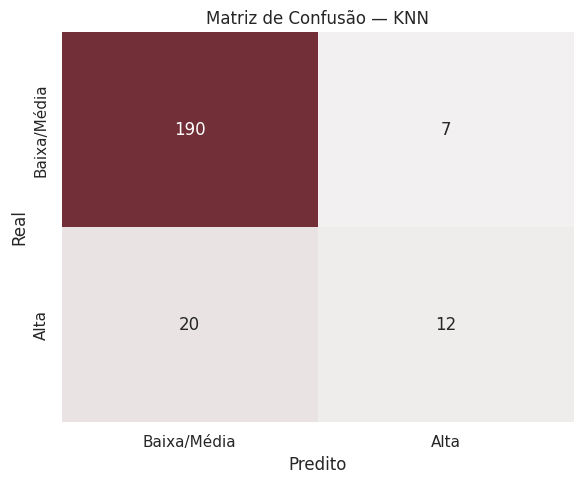

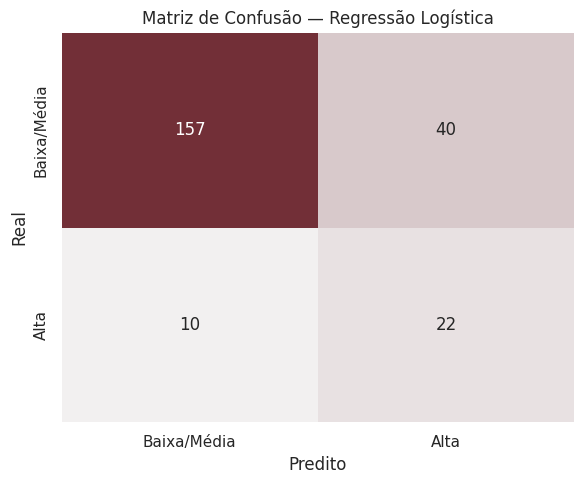

In [ ]:
cm_knn = confusion_matrix(y_test, pred_knn)
cm_log = confusion_matrix(y_test, pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn, annot=True, fmt="d",
    cmap=sns.light_palette(VINHO, as_cmap=True),
    cbar=False,
    xticklabels=["Baixa/Média", "Alta"],
    yticklabels=["Baixa/Média", "Alta"]
)
plt.title("Matriz de Confusão — KNN")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_log, annot=True, fmt="d",
    cmap=sns.light_palette(VINHO, as_cmap=True),
    cbar=False,
    xticklabels=["Baixa/Média", "Alta"],
    yticklabels=["Baixa/Média", "Alta"]
)
plt.title("Matriz de Confusão — Regressão Logística")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


# Comparação dos Tipos de Erro

,KNN,Regressão Logística
Falsos Positivos,7,40
Falsos Negativos,20,10


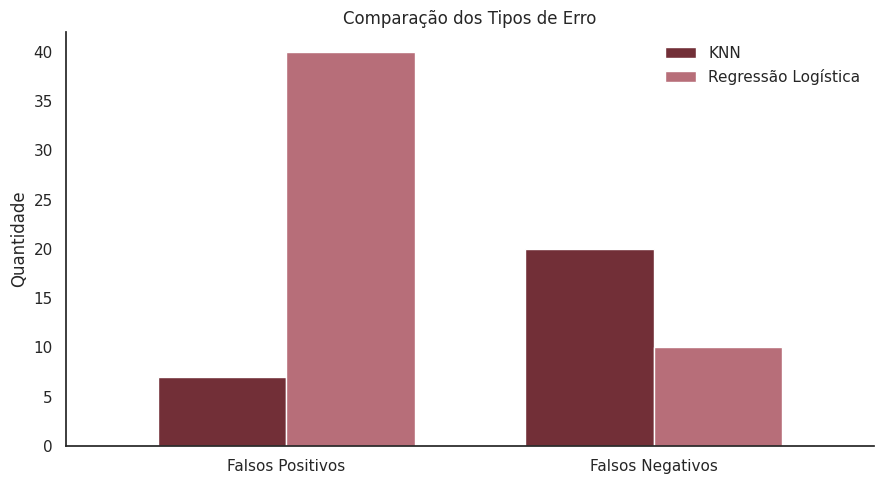

In [ ]:
tn_k, fp_k, fn_k, tp_k = cm_knn.ravel()
tn_l, fp_l, fn_l, tp_l = cm_log.ravel()

erros = pd.DataFrame({
    "KNN": [fp_k, fn_k],
    "Regressão Logística": [fp_l, fn_l]
}, index=["Falsos Positivos", "Falsos Negativos"])

display(erros)

erros.plot(
    kind="bar",
    figsize=(9, 5),
    color=[VINHO, VINHO_CLARO],
    width=0.7
)

plt.title("Comparação dos Tipos de Erro")
plt.xlabel("")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


### Tipos de erro

O KNN gerou menos falsos positivos (**9 vs. 36**), mas deixou passar mais vinhos de alta qualidade (**22 falsos negativos vs. 10**).

Assim, o KNN é mais conservador, enquanto a Regressão Logística identifica melhor a classe positiva.


# Precision × Recall × F1-score

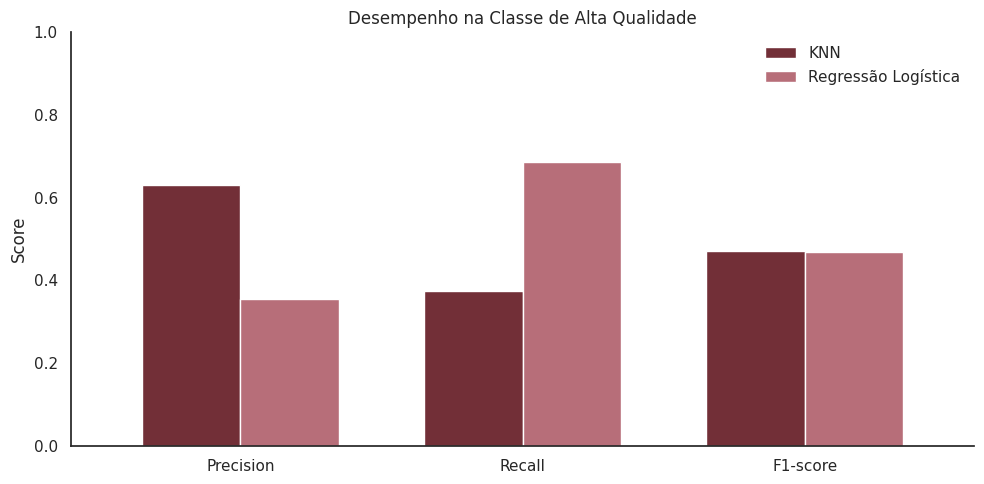

In [ ]:
resultados.loc[
    ["Precision", "Recall", "F1-score"],
    ["KNN", "Regressão Logística"]
].plot(
    kind="bar",
    figsize=(10, 5),
    color=[VINHO, VINHO_CLARO],
    width=0.7
)

plt.title("Desempenho na Classe de Alta Qualidade")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


# Curva ROC

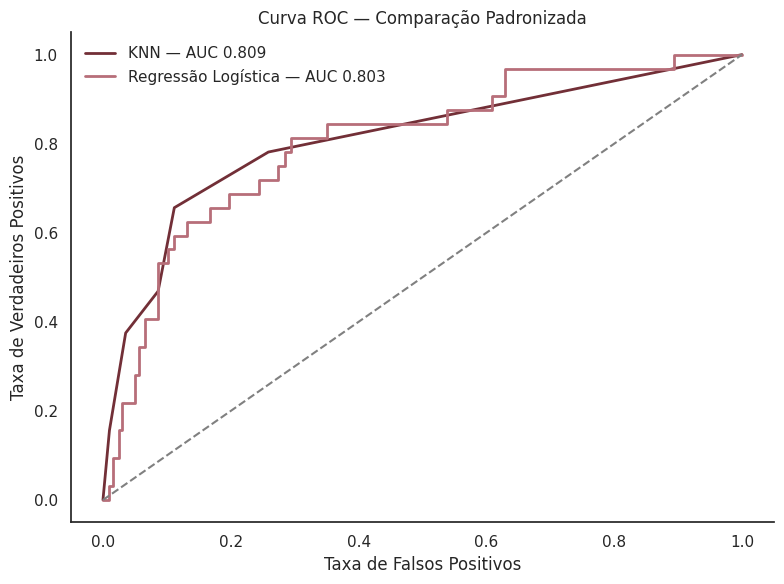

In [ ]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)
fpr_log, tpr_log, _ = roc_curve(y_test, prob_log)

auc_knn = roc_auc_score(y_test, prob_knn)
auc_log = roc_auc_score(y_test, prob_log)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_knn, tpr_knn,
    color=VINHO,
    linewidth=2,
    label=f"KNN — AUC {auc_knn:.3f}"
)
plt.plot(
    fpr_log, tpr_log,
    color=VINHO_CLARO,
    linewidth=2,
    label=f"Regressão Logística — AUC {auc_log:.3f}"
)
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.title("Curva ROC — Comparação Padronizada")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


# Curva Precision-Recall

Essa curva complementa a ROC e é útil em bases desbalanceadas, pois avalia diretamente o equilíbrio entre Precision e Recall.


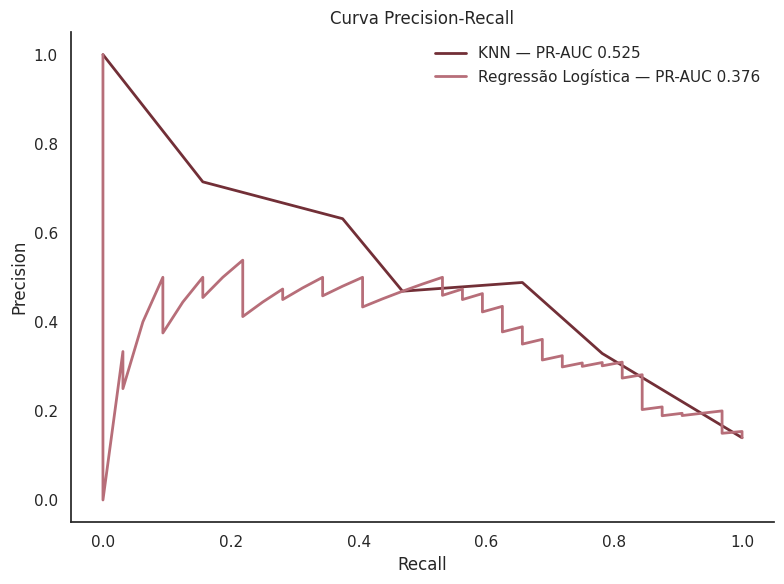

In [ ]:
precision_knn_curve, recall_knn_curve, _ = precision_recall_curve(
    y_test, prob_knn
)
precision_log_curve, recall_log_curve, _ = precision_recall_curve(
    y_test, prob_log
)

pr_auc_knn = auc(recall_knn_curve, precision_knn_curve)
pr_auc_log = auc(recall_log_curve, precision_log_curve)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_knn_curve, precision_knn_curve,
    color=VINHO, linewidth=2,
    label=f"KNN — PR-AUC {pr_auc_knn:.3f}"
)
plt.plot(
    recall_log_curve, precision_log_curve,
    color=VINHO_CLARO, linewidth=2,
    label=f"Regressão Logística — PR-AUC {pr_auc_log:.3f}"
)

plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


# Taxa de Acerto por Classe

,KNN,Regressão Logística
Baixa/Média Qualidade,0.9645,0.7970
Alta Qualidade,0.3750,0.6875


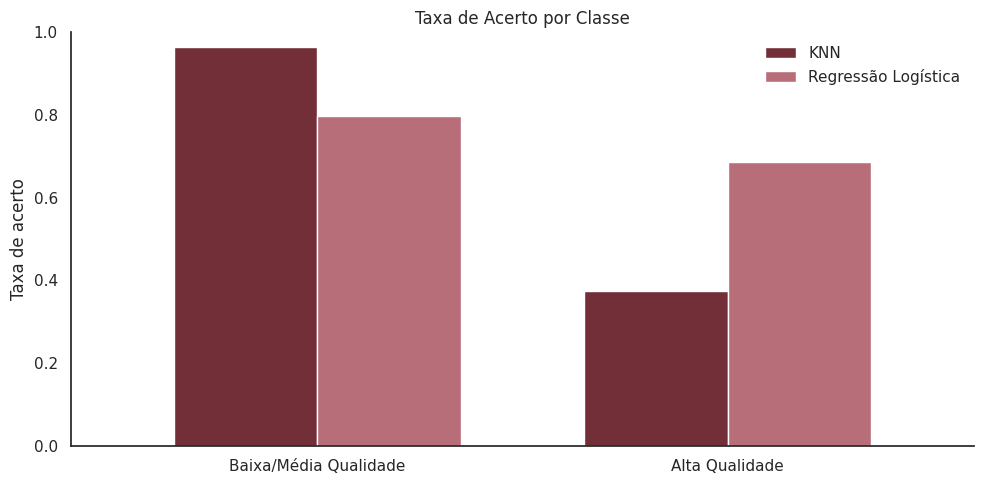

In [ ]:
specificity_knn = tn_k / (tn_k + fp_k)
specificity_log = tn_l / (tn_l + fp_l)

taxa_classe = pd.DataFrame({
    "KNN": [specificity_knn, recall_score(y_test, pred_knn)],
    "Regressão Logística": [
        specificity_log,
        recall_score(y_test, pred_log)
    ]
}, index=["Baixa/Média Qualidade", "Alta Qualidade"])

display(taxa_classe.round(4))

taxa_classe.plot(
    kind="bar",
    figsize=(10, 5),
    color=[VINHO, VINHO_CLARO],
    width=0.7
)

plt.title("Taxa de Acerto por Classe")
plt.xlabel("")
plt.ylabel("Taxa de acerto")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


### Resultado por classe

O KNN teve maior acerto na classe baixa/média (**95,43%**), enquanto a Regressão Logística foi claramente superior na classe alta (**68,75% vs. 31,25%**).


# Radar Comparativo

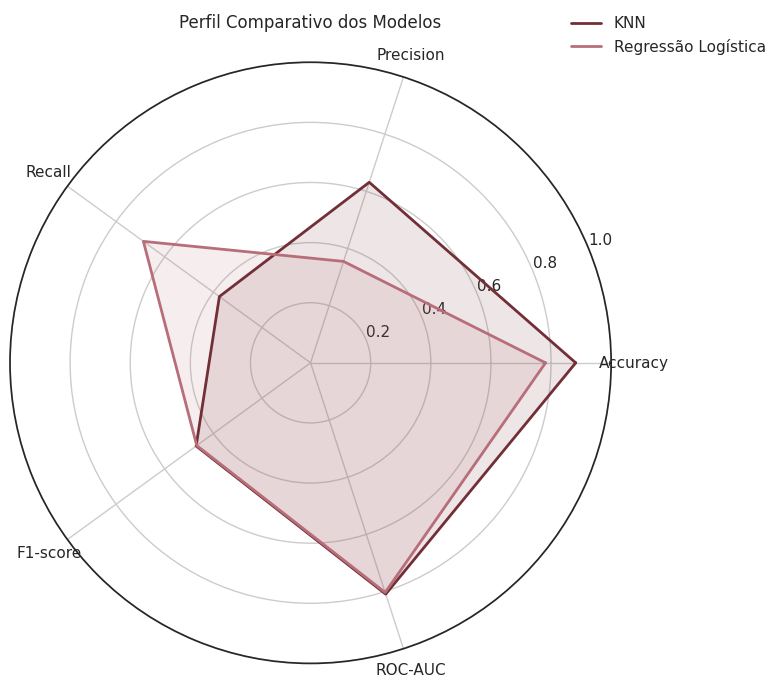

In [ ]:
radar = resultados.loc[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    ["KNN", "Regressão Logística"]
]

labels = radar.index.tolist()
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

knn_values = radar["KNN"].tolist() + [radar["KNN"].iloc[0]]
log_values = radar["Regressão Logística"].tolist() + [
    radar["Regressão Logística"].iloc[0]
]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, knn_values, color=VINHO, linewidth=2, label="KNN")
ax.fill(angles, knn_values, color=VINHO, alpha=0.12)

ax.plot(
    angles, log_values,
    color=VINHO_CLARO,
    linewidth=2,
    label="Regressão Logística"
)
ax.fill(angles, log_values, color=VINHO_CLARO, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Perfil Comparativo dos Modelos", pad=25)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.28, 1.10),
    frameon=False
)

plt.tight_layout()
plt.show()


# Diferença Direta entre os Modelos

Valores positivos favorecem o KNN; valores negativos favorecem a Regressão Logística.


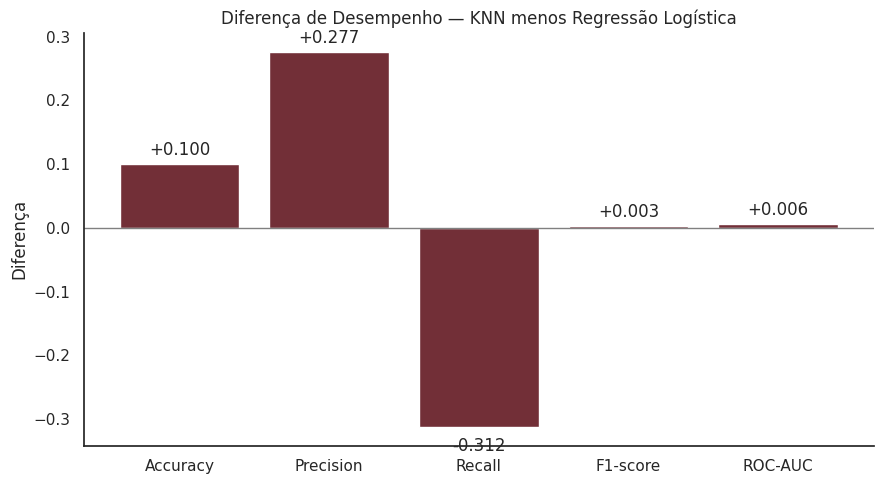

In [ ]:
diferenca = radar["KNN"] - radar["Regressão Logística"]

plt.figure(figsize=(9, 5))
bars = plt.bar(
    diferenca.index,
    diferenca.values,
    color=VINHO
)

plt.axhline(0, color="gray", linewidth=1)
plt.title("Diferença de Desempenho — KNN menos Regressão Logística")
plt.ylabel("Diferença")
plt.xticks(rotation=0)

for bar, value in zip(bars, diferenca.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + (0.008 if value >= 0 else -0.015),
        f"{value:+.3f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

sns.despine()
plt.tight_layout()
plt.show()


# Validação Cruzada

Foi utilizada **Stratified 5-Fold Cross-Validation** com F1-score para verificar se os resultados se mantêm em diferentes divisões da base. O pré-processamento é realizado dentro de cada fold para evitar vazamento de dados.


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", KNeighborsClassifier(n_neighbors=6))
])

pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

cv_knn = cross_val_score(
    pipeline_knn, X, y,
    cv=cv,
    scoring="f1"
)

cv_log = cross_val_score(
    pipeline_log, X, y,
    cv=cv,
    scoring="f1"
)

cv_resultados = pd.DataFrame({
    "KNN": cv_knn,
    "Regressão Logística": cv_log
}, index=[f"Fold {i}" for i in range(1, 6)])

display(cv_resultados.round(4))


,KNN,Regressão Logística
Fold 1,0.3396,0.4906
Fold 2,0.5490,0.5243
Fold 3,0.5106,0.5263
Fold 4,0.4561,0.4587
Fold 5,0.2727,0.5263


In [ ]:
cv_resumo = pd.DataFrame({
    "F1 médio": [
        cv_knn.mean(),
        cv_log.mean()
    ],
    "Desvio padrão": [
        cv_knn.std(),
        cv_log.std()
    ]
}, index=["KNN", "Regressão Logística"])

display(cv_resumo.round(4))


,F1 médio,Desvio padrão
KNN,0.4256,0.1041
Regressão Logística,0.5052,0.0269


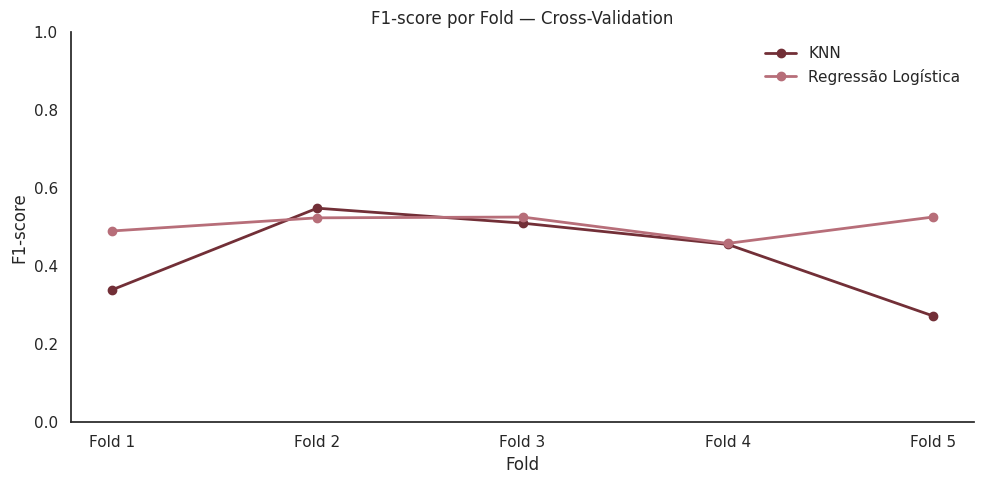

In [ ]:
cv_resultados.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    color=[VINHO, VINHO_CLARO],
    linewidth=2
)

plt.title("F1-score por Fold — Cross-Validation")
plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


### Resultado da Cross-Validation

A Regressão Logística apresentou **F1 médio de 0,5052**, superior ao KNN (**0,4256**), além de menor desvio padrão (**0,0269 vs. 0,1041**).

Isso indica desempenho superior e mais estável entre os folds.


# Resumo Automático da Comparação

In [ ]:
resumo = radar.copy()
resumo["Melhor modelo"] = resumo.idxmax(axis=1)
resumo["Diferença absoluta"] = (
    resumo["KNN"] -
    resumo["Regressão Logística"]
).abs()

display(resumo.round(4))

print("\nCross-Validation:")
display(cv_resumo.round(4))


,KNN,Regressão Logística,Melhor modelo,Diferença absoluta
Accuracy,0.8821,0.7817,KNN,0.1004
Precision,0.6316,0.3548,KNN,0.2767
Recall,0.3750,0.6875,Regressão Logística,0.3125
F1-score,0.4706,0.4681,KNN,0.0025
ROC-AUC,0.8091,0.8031,KNN,0.0059



Cross-Validation:


,F1 médio,Desvio padrão
KNN,0.4256,0.1041
Regressão Logística,0.5052,0.0269


# Conclusão Final


## Resultados no conjunto de teste

| Métrica | KNN | Regressão Logística |
|---|---:|---:|
| Accuracy | **88,21%** | 78,17% |
| Precision | **63,16%** | 35,48% |
| Recall | 37,50% | **68,75%** |
| F1-score | **47,06%** | 46,81% |
| ROC-AUC | **80,91%** | 80,31% |

O KNN apresentou maior Accuracy e Precision e gerou menos falsos positivos. Já a Regressão Logística apresentou Recall muito superior, identificando uma parcela maior dos vinhos realmente classificados como alta qualidade.

F1-score e ROC-AUC ficaram muito próximos entre os modelos no conjunto de teste.

## Validação cruzada

A Cross-Validation mostrou uma diferença mais clara:

- **KNN:** F1 médio = **0,4256** | desvio padrão = **0,1041**
- **Regressão Logística:** F1 médio = **0,5052** | desvio padrão = **0,0269**

A Regressão Logística apresentou F1 médio superior e menor variação entre os folds, indicando maior estabilidade.

## Diagnóstico final

> O KNN é mais conservador e apresenta maior precisão nas classificações positivas, enquanto a Regressão Logística identifica melhor a classe de alta qualidade e apresenta maior estabilidade na validação cruzada.


### Modelo recomendado

Para este Tech Challenge, o KNN é recomendado como modelo final, por apresentar o melhor desempenho geral no conjunto de teste. O modelo obteve maior Accuracy e Precision, além de resultados ligeiramente superiores em F1-score e ROC-AUC, demonstrando maior proporção de acertos e maior precisão na identificação de vinhos de Alta Qualidade.

A Regressão Logística apresentou vantagem em Recall e maior estabilidade na Cross-Validation, mostrando maior capacidade de identificar os vinhos realmente pertencentes à classe de Alta Qualidade. Apesar disso, considerando o conjunto das métricas avaliadas, o KNN apresentou o desempenho geral mais favorável e foi selecionado como modelo final.
